# Практическое задание №4.
**Сессионное задание**

*   Выполнил: Стояловский Константин
*   Группа: M25-555


# 0. Импортируем необходимые библиотеки

In [ ]:
!pip install opendatasets

In [ ]:
import time

import opendatasets as od
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np

import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import NearestNeighbors

import itertools

RANDOM_STATE = 42

# 1. Исследование и анализ датасета

In [ ]:
# Загружаем датасет с kaggle.
od.download('https://www.kaggle.com/competitions/signal-types-classification/', force=True)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kkkonst
Your Kaggle Key: ··········


100%|██████████| 13.2M/13.2M [00:00<00:00, 144MB/s]


Extracting archive ./signal-types-classification/signal-types-classification.zip to ./signal-types-classification


In [ ]:
df_train = pd.read_csv('/content/signal-types-classification/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

print(f'Форма датасета: {df_train.shape}')
print(f'Число строк: {df_train.shape[0]}, число столбцов: {df_train.shape[1]}')

# Просмотрим как выглядят первые 10 строк.
df_train.head(10)

Форма датасета: (23479, 505)
Число строк: 23479, число столбцов: 505


,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN
5,22773382,1310,61,500,14825,14820,14822,14824,14823,14823,...,14823,14817,14820,14813,14819,14821,14820,14828,14822,NaN
6,26520366,1154,195,500,14824,14820,14818,14824,14820,14823,...,14818,14820,14820,14823,14818,14824,14826,14821,14818,NaN
7,70574842,1904,31,500,14824,14820,14825,14823,14824,14826,...,14820,14823,14824,14826,14824,14821,14824,14826,14820,NaN
8,73301918,1083,397,500,14824,14818,14823,14820,14828,14824,...,14819,14824,14822,14821,14820,14819,14820,14823,14824,NaN
9,74388134,1654,391,500,14825,14824,14821,14820,14821,14824,...,14819,14823,14824,14820,14818,14816,14823,14822,14816,NaN


In [ ]:
# Подробнее взглянем на датасеты.
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB


In [ ]:
# Основные статистики всех числовых признаков.
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
0,23479.0,1.009742e+11,5.715472e+10,2890276.0,5.156311e+10,1.014553e+11,1.502418e+11,2.000107e+11
1,23479.0,8.691600e+02,5.729058e+02,0.0,3.730000e+02,8.100000e+02,1.341000e+03,1.998000e+03
2,23479.0,3.721917e+02,4.703917e+02,10.0,6.400000e+01,1.720000e+02,4.830000e+02,3.370000e+03
3,23479.0,5.000000e+02,0.000000e+00,500.0,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
4,23479.0,1.482297e+04,2.805884e+00,14812.0,1.482100e+04,1.482300e+04,1.482400e+04,1.483400e+04
...,...,...,...,...,...,...,...,...
500,23479.0,1.482228e+04,3.268458e+00,14798.0,1.482000e+04,1.482300e+04,1.482400e+04,1.483300e+04
501,23479.0,1.482228e+04,3.251192e+00,14804.0,1.482000e+04,1.482300e+04,1.482400e+04,1.483400e+04
502,23479.0,1.482229e+04,3.253340e+00,14800.0,1.482000e+04,1.482300e+04,1.482400e+04,1.483300e+04
503,23479.0,1.482228e+04,3.242307e+00,14802.0,1.482000e+04,1.482300e+04,1.482400e+04,1.483500e+04


In [ ]:
# Проверка пропущенных значений.
missing_values = df_train.isnull().sum()
total_rows = len(df_train)

# Фильтруем только столбцы с пропусками.
missing_data = missing_values[missing_values > 0].to_frame(name='Missing_Count')
missing_data['Missing_Percentage'] = (missing_data['Missing_Count'] / total_rows) * 100

missing_data

,Missing_Count,Missing_Percentage
504,23479,100.0


Столбец `504` полностью пуст! Удалим его.

In [ ]:
df_clean = df_train.dropna(axis=1, how='all')
print(f'Форма после удаления пустых столбцов: {df_clean.shape}')

Форма после удаления пустых столбцов: (23479, 504)


Переименуем столбцы для удобства.

In [ ]:
cols = ['ID', 'Param1', 'Param2', 'Param3'] + [f'T{i}' for i in range(500)]
df_clean.columns = cols

df_clean.head()

,ID,Param1,Param2,Param3,T0,T1,T2,T3,T4,T5,...,T490,T491,T492,T493,T494,T495,T496,T497,T498,T499
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


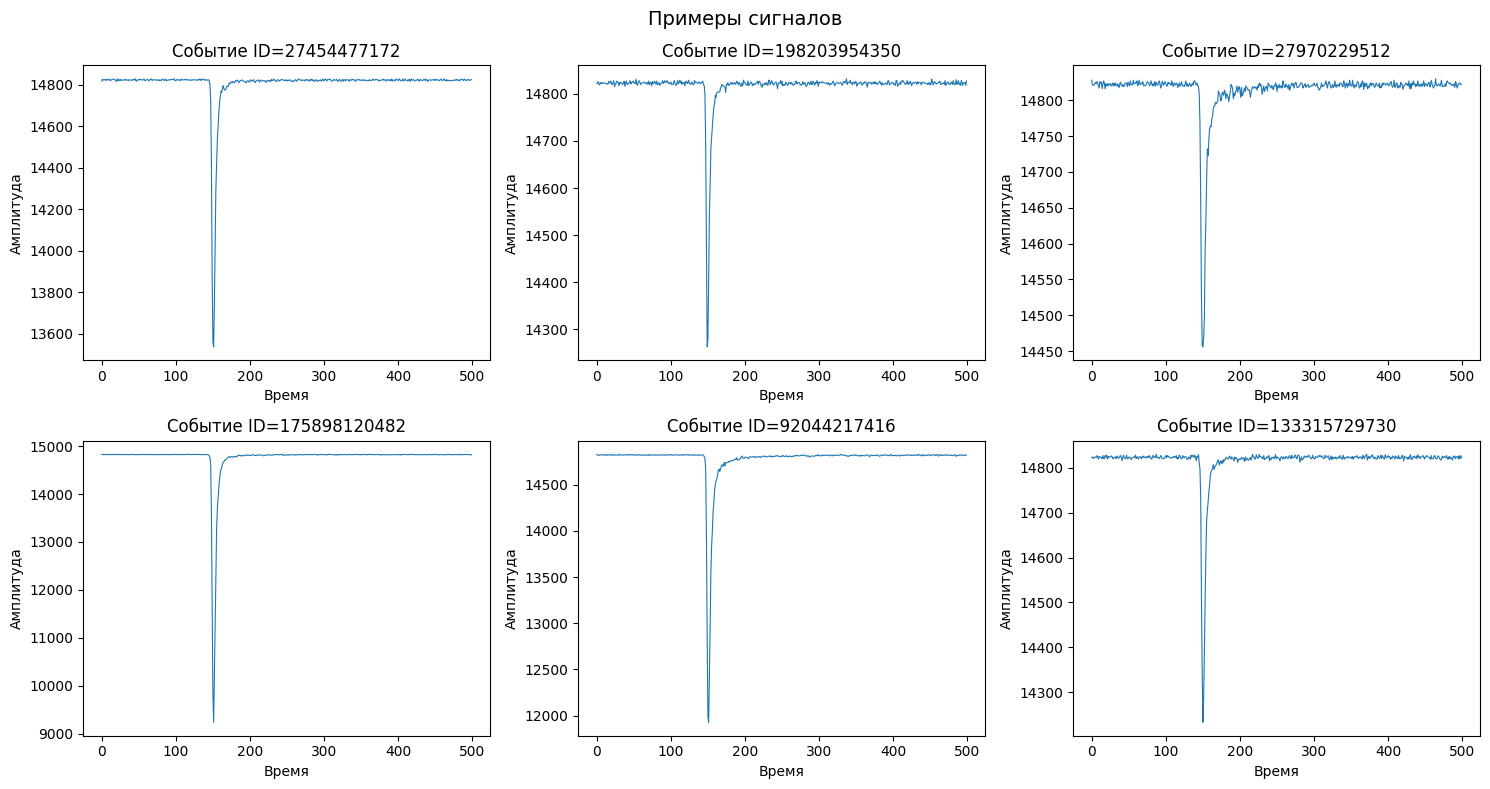

In [ ]:
# Примеры сигналов.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sample_ids = np.random.choice(df_clean.index, size=6, replace=False)

for ax, idx in zip(axes.flatten(), sample_ids):
    row = df_clean.loc[idx, 'T0':'T499']
    ax.plot(row.values, linewidth=0.8)
    ax.set_title(f'Событие ID={df_clean.loc[idx, "ID"]}')
    ax.set_xlabel('Время')
    ax.set_ylabel('Амплитуда')

plt.suptitle('Примеры сигналов', fontsize=14)
plt.tight_layout()
plt.show()

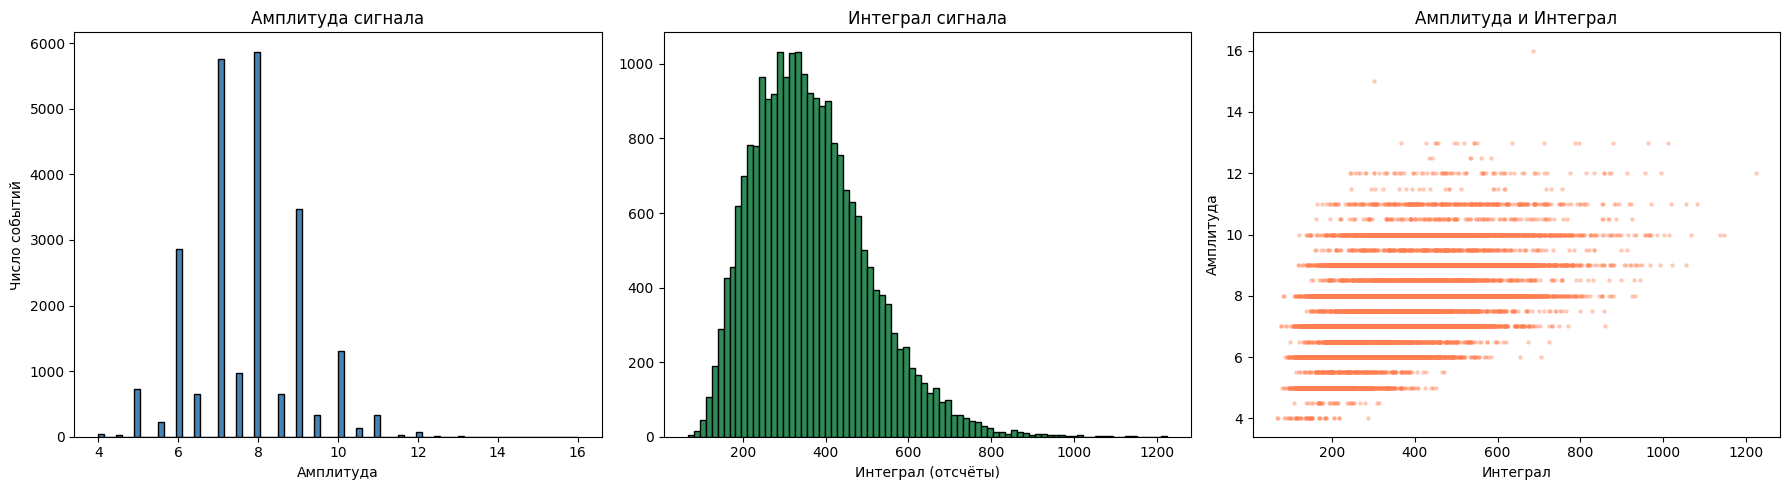

In [ ]:
# Распределение ключевых характеристик.
baseline = df_clean.loc[:, 'T0':'T49'].median(axis=1)
signal_amplitude = df_clean.loc[:, 'T0':'T499'].max(axis=1) - baseline
signal_integral = (df_clean.loc[:, 'T0':'T499'] - baseline.values.reshape(-1,1)).clip(lower=0).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(signal_amplitude, bins=80, color='steelblue', edgecolor='black')
axes[0].set_title('Амплитуда сигнала')
axes[0].set_xlabel('Амплитуда')
axes[0].set_ylabel('Число событий')

axes[1].hist(signal_integral, bins=80, color='seagreen', edgecolor='black')
axes[1].set_title('Интеграл сигнала')
axes[1].set_xlabel('Интеграл (отсчёты)')

axes[2].scatter(signal_integral, signal_amplitude, alpha=0.3, s=5, c='coral')
axes[2].set_title('Амплитуда и Интеграл')
axes[2].set_xlabel('Интеграл')
axes[2].set_ylabel('Амплитуда')
plt.tight_layout()
plt.show()

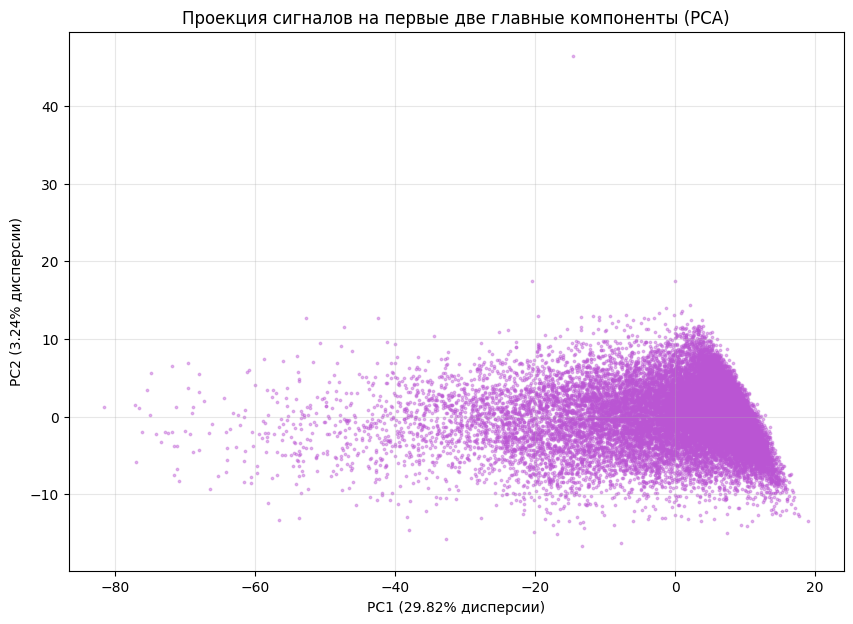

In [ ]:
# PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.loc[:, 'T0':'T499'])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=3, c='mediumorchid')
plt.title('Проекция сигналов на первые две главные компоненты (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.grid(alpha=0.3)
plt.show()

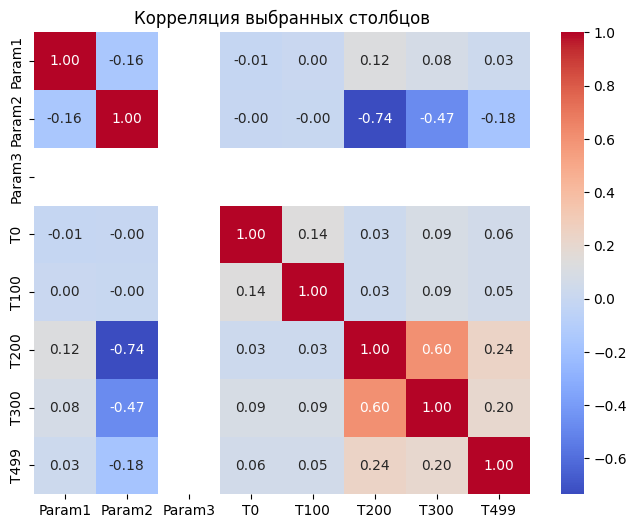

In [ ]:
# Корреляция между малым набором признаков.
subset_cols = ['Param1', 'Param2', 'Param3', 'T0', 'T100', 'T200', 'T300', 'T499']
corr = df_clean[subset_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция выбранных столбцов')
plt.show()

**Выводы по EDA:**

- Датасет содержит 23 479 событий и 504 информативных столбца. Первые 4 столбца являются служебными параметрами, остальные 500 — оцифрованный сигнал (временные отсчёты). Столбец 504 оказался полностью пустым и был удалён.

- После удаления пустого столбца пропущенные значения в данных отсутствуют.

- Графики случайных сигналов демонстрируют импульсы разной формы и амплитуды. Наблюдаются как быстрые короткие импульсы, так и более широкие сигналы, что может соответствовать разным типам частиц.

- Гистограмма амплитуды показывает бимодальную (или полимодальную) структуру, что указывает на присутствие как минимум двух популяций сигналов с разной энергией. Интегральное распределение коррелирует с амплитудным, но содержит дополнительные различия по длительности импульсов.

- Между отдельными временными отсчётами наблюдается высокая корреляция (что ожидаемо для соседних выборок), однако служебные параметры практически не коррелируют с амплитудными значениями, что делает их потенциально полезными дополнительными признаками.

# 2. Предобработка данных.

1. Уже сделано: Удалили полностью пустой столбец.
2. Предлагаю удалить ID, т.к. он бесполезен в нашей задачи кластеризации.
3. Создадим физические признаки.
4. Проведём выравнивание.

In [ ]:
# Убираем ID (но сохраним в отдельной переменной на всякий случай).
event_id = df_clean['ID']
df_feat = df_clean.drop(columns=['ID'])

In [ ]:
# Выравнивание по медиане.
baseline_vals = df_feat.loc[:, 'T0':'T49'].median(axis=1)
signal_cols = [f'T{i}' for i in range(500)]
df_signals_corrected = df_feat[signal_cols].sub(baseline_vals, axis=0)


In [ ]:
signals = df_signals_corrected.values

# Амплитуда.
amplitude = signals.max(axis=1)

# Интеграл.
integral = np.clip(signals, 0, None).sum(axis=1)

# Положение максимума.
peak_pos = signals.argmax(axis=1)

# Среднее значение.
mean_signal = signals.mean(axis=1)

# Стандартное отклонение.
std_signal = signals.std(axis=1)

# Энергия сигнала.
energy = np.square(signals).sum(axis=1)

physics_features = pd.DataFrame({
    'amplitude': amplitude,
    'integral': integral,
    'peak_pos': peak_pos,
    'mean_signal': mean_signal,
    'std_signal': std_signal,
    'energy': energy
})

In [ ]:
df_proc = pd.concat(
    [
        df_feat[['Param1', 'Param2', 'Param3']],
        physics_features,
        df_signals_corrected
    ],
    axis=1
)

In [ ]:
# Удаляем столбцы с околонулевой дисперсией.
selector = VarianceThreshold(threshold=0.01)
df_filtered = pd.DataFrame(selector.fit_transform(df_proc), columns=df_proc.columns[selector.get_support()])

print(f'Число признаков после фильтрации: {df_filtered.shape[1]}')

Число признаков после фильтрации: 508


# 3. Feature Engineering

Сделаем стандартизацию с помощью `RobustScaler`.

Как показывает практика, т.к. у нас ~500 временных отсчетов, лучше всего не городить лишнего, PCA должен сам выделить наиболее информативные комбинации.
Несколько простых интерпретируемых признаков часто делают кластеры физически осмысленными и упрощают анализ.

P.s. Ну и это Каггл - он любит простое почему то :)

In [ ]:
# Стандартизация.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_filtered)

# 4. Подбор признаков, их анализ и оценка важности.

В задаче нет целевой переменной, поэтому прямо измерить важность для кластеризации нельзя...

# 5. Обучение нескольких моделей, их сравнение.

Протестируем модели:
1. KMeans
2. GaussianMixture
3. DBSCAN

Чтобы модели быстрее протестировались - урежу выборку, иначе придется ждать до посинения...

In [ ]:
# Снижение размерности (для ускорения и удаления шума).
pca = PCA(n_components=20, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Суммарная объяснённая дисперсия 20 компонент: {pca.explained_variance_ratio_.sum():.3f}')

Суммарная объяснённая дисперсия 20 компонент: 0.529


**В условии задания сказано:**

Кластеризовать сигналы на три кластера:
- Кластер 0 — сигналы, соответствующие первому типу частиц (гамма-кванты или нейтроны),
- Кластер 1 — сигналы, соответствующие второму типу частиц,
- Кластер 2 — сигналы, не поддающиеся однозначной классификации (аномальные, смешанные или выбросы).

Отсюда берем за кол-во классов значение - `3`

In [ ]:
k = 3
min_samples = 5

models = {}

In [ ]:
# KMeans.
start = time.time()

kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)
models['KMeans'] = kmeans_labels

print(f'KMeans: время {time.time()-start:.2f} с, кластеры {np.unique(kmeans_labels)}')

KMeans: время 0.81 с, кластеры [0 1 2]


In [ ]:
# Gaussian Mixture.
start = time.time()

gmm = GaussianMixture(
    n_components=k, random_state=RANDOM_STATE,
    covariance_type='tied', n_init=5
)
gmm_labels = gmm.fit_predict(X_pca)
models['GMM'] = gmm_labels

print(f'GMM: время {time.time()-start:.2f} с, кластеры {np.unique(gmm_labels)}')

GMM: время 17.32 с, кластеры [0 1 2]


In [ ]:
# DBSCAN (с ускоренным ball_tree).
start = time.time()

dbscan = DBSCAN(min_samples=min_samples, metric='euclidean', algorithm='ball_tree', n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_pca)
models['DBSCAN'] = dbscan_labels

print(f'DBSCAN: время {time.time()-start:.2f} с, кластеры {np.unique(dbscan_labels)}')
print(f'Выбросов (label=-1): {np.sum(dbscan_labels==-1)} из {len(dbscan_labels)}')

DBSCAN: время 2.54 с, кластеры [-1]
Выбросов (label=-1): 23479 из 23479


In [ ]:
# Оценка качества.
results = []

for name, labels in models.items():
    # Для DBSCAN исключаем шумовые точки при вычислении метрик.
    if name == 'DBSCAN':
        mask = labels != -1
        X_eval = X_pca[mask]
        labels_eval = labels[mask]

        if len(np.unique(labels_eval)) < 2:
            print(f'{name}: недостаточно кластеров для метрик (только шум или 1 кластер)')
            continue

        outliers_frac = 1 - mask.mean()
        print(f'{name}: доля выбросов = {outliers_frac:.2%}')
    else:
        X_eval = X_pca
        labels_eval = labels

    sil = silhouette_score(X_eval, labels_eval)
    db = davies_bouldin_score(X_eval, labels_eval)
    ch = calinski_harabasz_score(X_eval, labels_eval)
    results.append((name, sil, db, ch))
    print(f'{name} -> Silhouette: {sil:.4f}, Davies-Bouldin: {db:.4f}, Calinski-Harabasz: {ch:.1f}')

KMeans -> Silhouette: 0.3793, Davies-Bouldin: 1.0879, Calinski-Harabasz: 17604.4
GMM -> Silhouette: 0.4067, Davies-Bouldin: 1.5254, Calinski-Harabasz: 4875.4
DBSCAN: недостаточно кластеров для метрик (только шум или 1 кластер)


In [ ]:
# Сводная таблица.
df_scores = pd.DataFrame(results, columns=['Model', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'])

df_scores

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.379341,1.087869,17604.393818
1,GMM,0.406670,1.525445,4875.380906


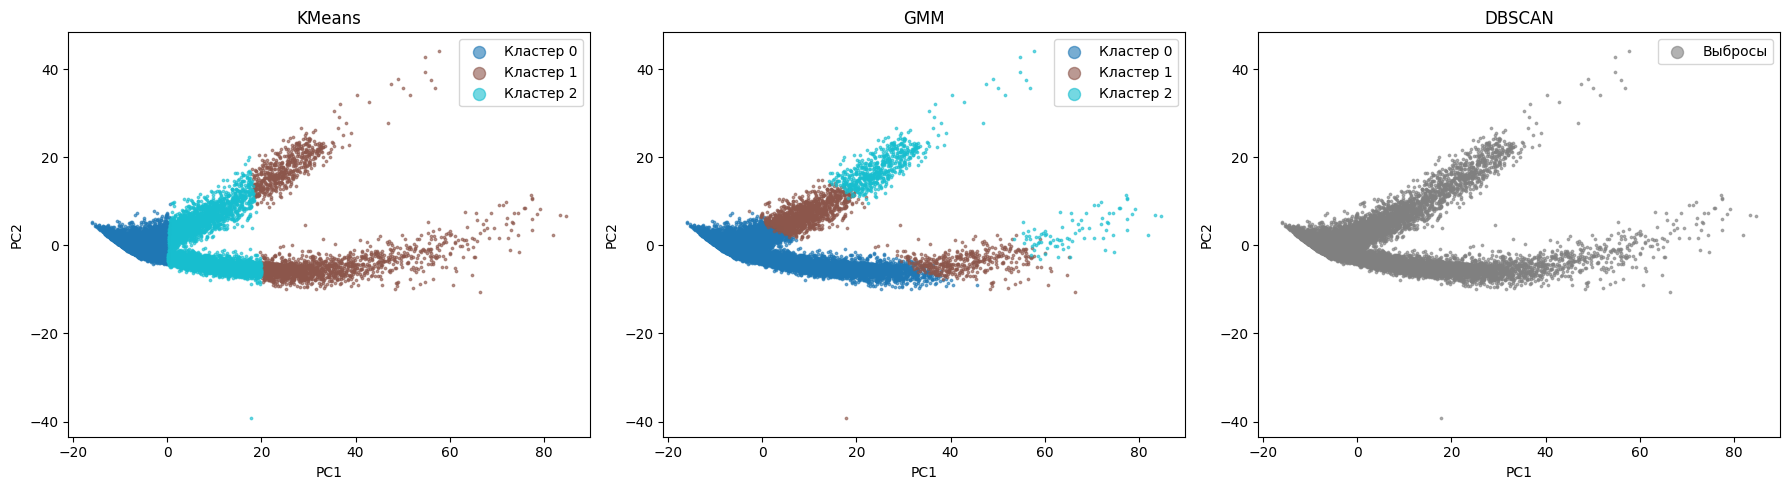

In [ ]:
# Визуализация кластеров в PCA-пространстве.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)

for ax, (name, labels) in zip(axes, models.items()):
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    for lbl, col in zip(unique_labels, colors):
        if lbl == -1:
            col = 'gray'
            label = 'Выбросы'
        else:
            label = f'Кластер {lbl}'

        ax.scatter(X_2d[labels == lbl, 0], X_2d[labels == lbl, 1], s=3, c=[col], label=label, alpha=0.6)

    ax.set_title(f'{name}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=5)

plt.tight_layout()
plt.show()

На тестах лучше всего показал себя `GaussianMixture`. Будем использовать его.

# 6. Подбор гиперпараметров.

In [ ]:
# Подбор для GMM.
cov_types = ['tied', 'diag', 'spherical']  # full не беру - долго...
reg_covars = [1e-4, 1e-3, 1e-2]
gmm_results = []

for cov_type, reg in itertools.product(cov_types, reg_covars):
    try:
        print(f'Тестируем: {cov_type} | {reg}')

        gmm = GaussianMixture(
            n_components=3,
            covariance_type=cov_type,
            reg_covar=reg, n_init=3,
            random_state=RANDOM_STATE
        )

        labels = gmm.fit_predict(X_pca)
        sil = silhouette_score(X_pca, labels, sample_size=20000)
        gmm_results.append({
            'cov_type': cov_type,
            'reg_covar': reg,
            'silhouette': sil
        })
    except Exception as e:
        print(f'Ошибка для {cov_type}, reg={reg}: {e}')

df_gmm = pd.DataFrame(gmm_results)

print("Лучшие параметры GMM:")
print(df_gmm.sort_values('silhouette', ascending=False).head(10))

Тестируем: tied | 0.0001
Тестируем: tied | 0.001
Тестируем: tied | 0.01
Тестируем: diag | 0.0001
Тестируем: diag | 0.001
Тестируем: diag | 0.01
Тестируем: spherical | 0.0001
Тестируем: spherical | 0.001
Тестируем: spherical | 0.01
Лучшие параметры GMM:
    cov_type  reg_covar  silhouette
2       tied     0.0100    0.409231
0       tied     0.0001    0.406190
1       tied     0.0010    0.403479
7  spherical     0.0010    0.330288
8  spherical     0.0100    0.329976
6  spherical     0.0001    0.328525
5       diag     0.0100    0.252255
4       diag     0.0010    0.249925
3       diag     0.0001    0.247526


Лучшим оказался:

`cov=tied, reg=1e-4: silhouette=0.409231`

# 7. Кластерзация.

In [ ]:
# GMM с лучшими параметрами.
gmm_final = GaussianMixture(
    n_components=3,
    covariance_type='tied',
    reg_covar=1e-4,
    max_iter=200,
    n_init=5,
    random_state=RANDOM_STATE
)

gmm_labels = gmm_final.fit_predict(X_pca)

# 8. Предсказание.

In [ ]:
# Строгая перенумерация для сабмишена.
mapping = {
    0: 1,
    1: 2,
    2: 0
}

final_labels = np.vectorize(mapping.get)(gmm_labels)

In [ ]:
# Формируем результат.
submission = pd.DataFrame({
    'index': np.arange(len(final_labels)),
    'cluster': final_labels
})

submission.to_csv('submission.csv', index=False)

print("Файл submission.csv сохранен. В бой!")

Файл submission.csv сохранен. В бой!


# 9. Результат на Kaggle.

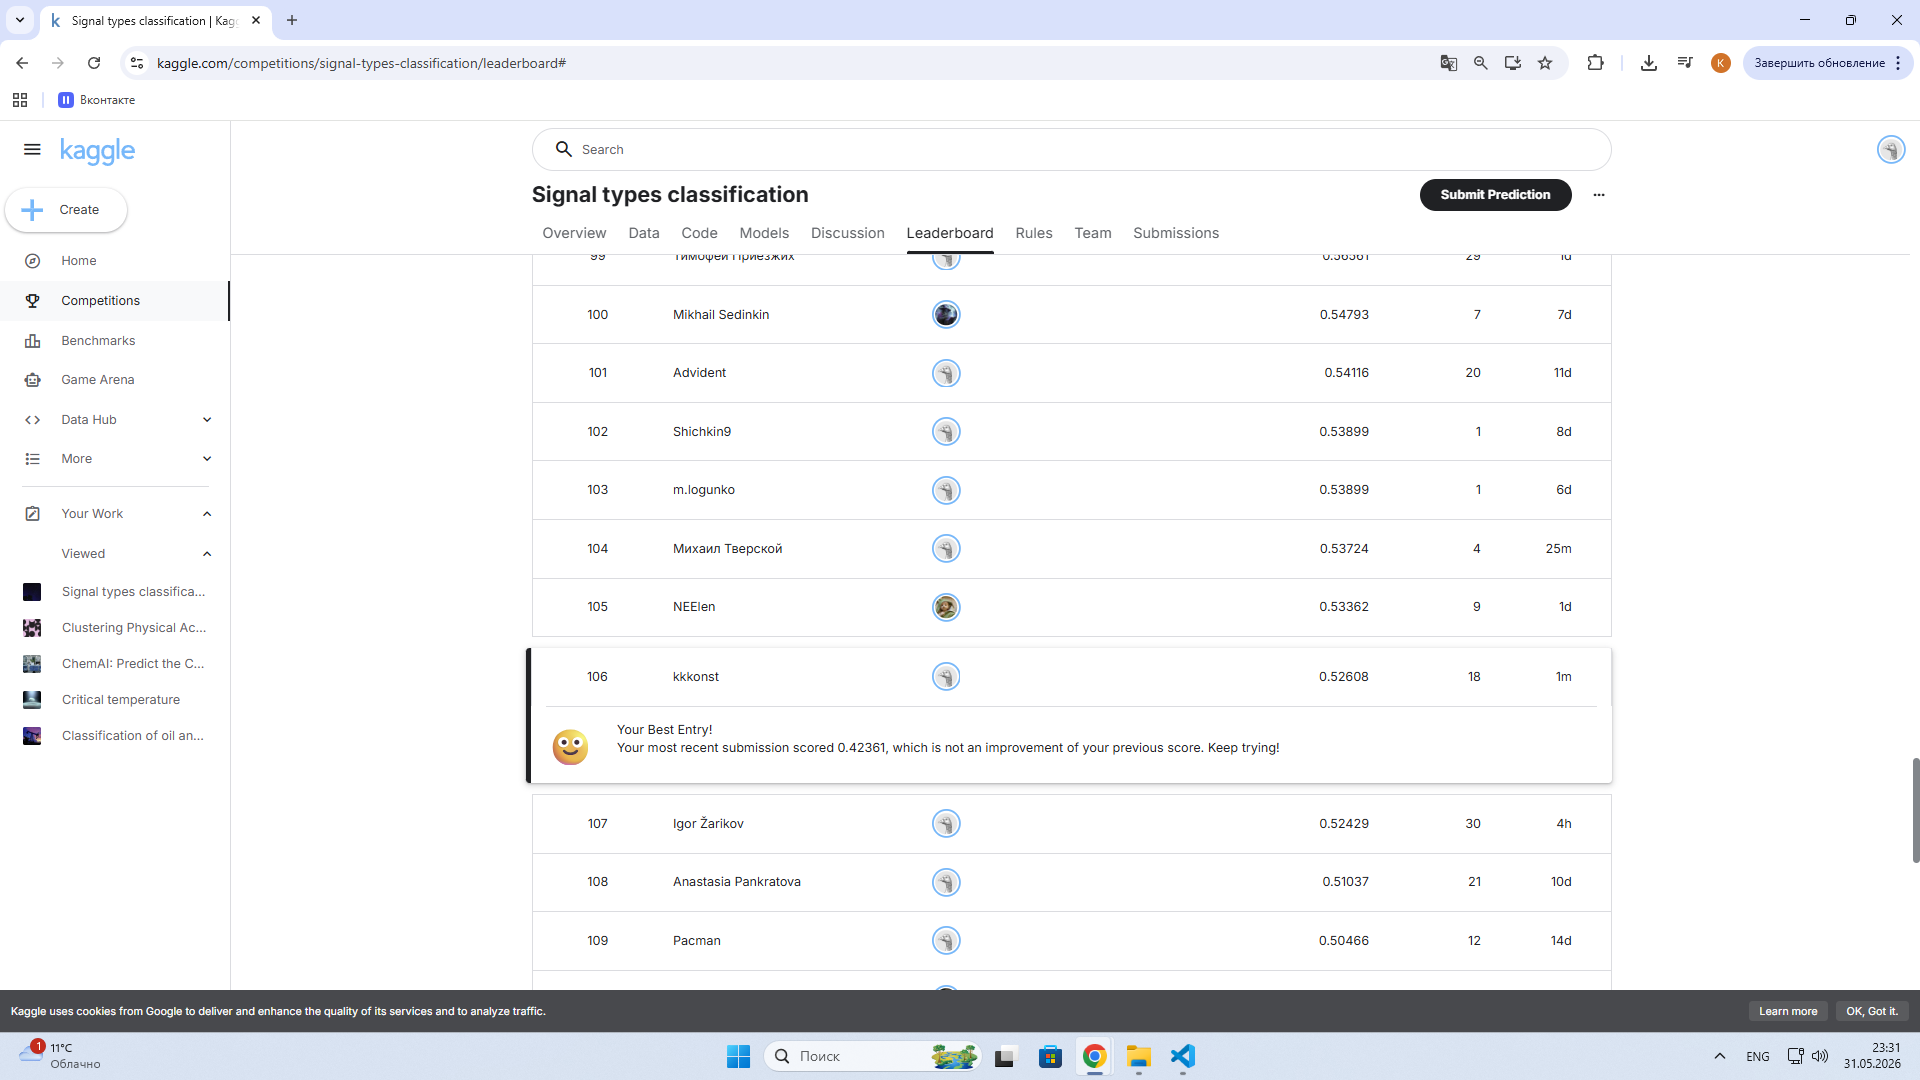

Ура! 🎉